# EDA

## Importing libaries

In [18]:
%pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt

## Loading Input datasets

Both datasets are collected from Kaggle. First we will perform EDA step.

In [2]:
enron_dataset = pd.read_csv('./data/raw/enron_spam_data.csv')

## Checking basic info likes samples amount, features amount in `enron_dataset`

In [4]:
enron_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 33716 entries, 0 to 33715
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Message ID  33716 non-null  int64
 1   Subject     33427 non-null  str  
 2   Message     33345 non-null  str  
 3   Spam/Ham    33716 non-null  str  
 4   Date        33716 non-null  str  
dtypes: int64(1), str(4)
memory usage: 1.3 MB


In [ ]:
enron_dataset.value_counts(enron_dataset['Spam/Ham'])

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64

## Plotting class distribution using Bar chart

Spam/Ham
spam    17171
ham     16545
Name: count, dtype: int64


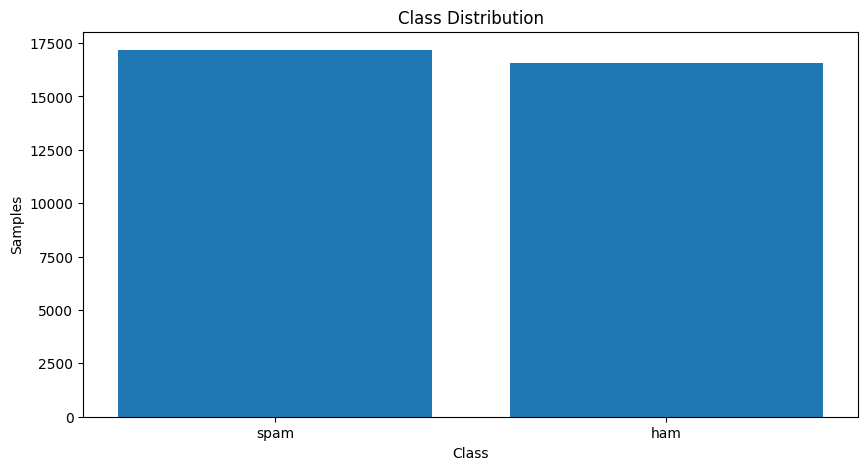

In [ ]:
# Plotting bar chart, using Matplotlib library
colors = sns.color_palette(palette='bright')
# Counting the frequency of SPAM/HAM labels to visualize the bar chart
label_counts = enron_dataset['Spam/Ham'].value_counts()
labels = ['spam','ham']

print(label_counts)

# Setting figure size
plt.figure(figsize=(10, 5))

# Creating bar chart
plt.bar(labels, label_counts)

# Adding title and labels
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Samples")

plt.show()


## Investigate empty `subject` or `body text` features

We will use a pie chart to show the percentage of samples missing either the `Subject` or `Message` feature, as well as the percentage missing both

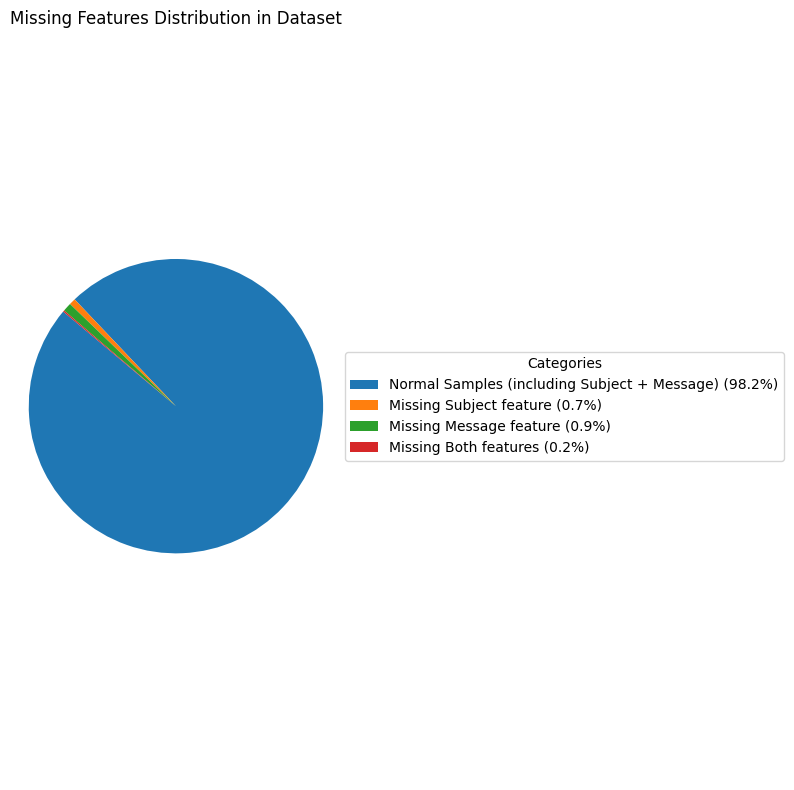

In [ ]:
total_rows = len(enron_dataset)
missing_subject = len(enron_dataset[enron_dataset['Subject'].isnull()])
missing_message = len(enron_dataset[enron_dataset['Message'].isnull()])
missing_both = len(enron_dataset[enron_dataset['Subject'].isnull() & enron_dataset['Message'].isnull()])

only_missing_subject = missing_subject - missing_both
only_missing_message = missing_message - missing_both
complete_data = total_rows - (only_missing_subject + only_missing_message + missing_both)

labels = ['Normal Samples (including Subject + Message)', 'Missing Subject feature', 'Missing Message feature', 'Missing Both features']
sizes = [complete_data, only_missing_subject, only_missing_message, missing_both]

percentages = [100 * s / total_rows for s in sizes]
legend_labels = [f'{label} ({pct:.1f}%)' for label, pct in zip(labels, percentages)]

plt.figure(figsize=(8, 8))
plt.pie(sizes, startangle=140)
plt.title('Missing Features Distribution in Dataset')
plt.legend(legend_labels, title="Categories", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.axis('equal')
plt.tight_layout()
plt.show()

Based on missing status, we will use bar chart to investigate labels distribution 

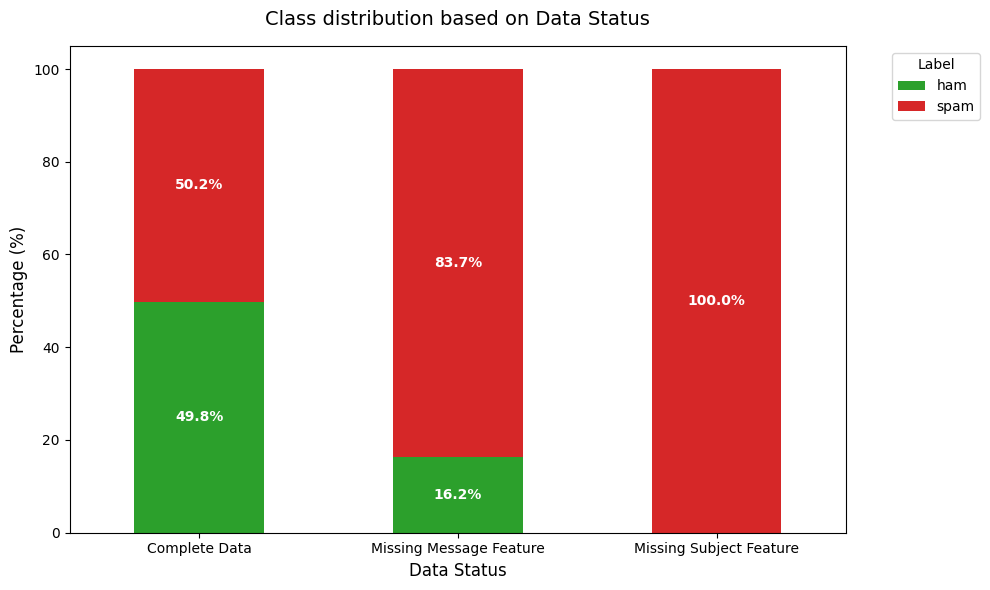

In [ ]:

conditions = [
    enron_dataset['Subject'].isnull() & enron_dataset['Message'].isnull(),
    enron_dataset['Subject'].isnull() & enron_dataset['Message'].notnull(),
    enron_dataset['Subject'].notnull() & enron_dataset['Message'].isnull(),
    enron_dataset['Subject'].notnull() & enron_dataset['Message'].notnull()
]
choices = ['Missing Both', 'Missing Subject Feature', 'Missing Message Feature', 'Complete Data']

enron_dataset['Missing_Status'] = np.select(conditions, choices, default='Unknown')

cross_tab = pd.crosstab(enron_dataset['Missing_Status'], enron_dataset['Spam/Ham'])


df_plot = enron_dataset[enron_dataset['Missing_Status'] != 'Missing Both']
cross_tab_pct = pd.crosstab(df_plot['Missing_Status'], df_plot['Spam/Ham'], normalize='index') * 100

ax = cross_tab_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#2ca02c', '#d62728'])

plt.title('Class distribution based on Data Status', fontsize=14, pad=15)
plt.xlabel('Data Status', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=0)

plt.legend(title='Label', bbox_to_anchor=(1.05, 1), loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    
    if height > 0:
        ax.text(x + width/2, 
                y + height/2, 
                f'{height:.1f}%', 
                ha='center', 
                va='center', 
                color='white', 
                fontweight='bold')

plt.tight_layout()
plt.show()

Since the samples that missed `Subject` Feature are `SPAM` label only, we will check the body text or message of these samples, previewing first 5 samples and tails

In [ ]:
only_missing_subject_df = enron_dataset[enron_dataset['Subject'].isnull() & enron_dataset['Message'].notnull()]
only_missing_subject_df['Message'].head()

3699    holiday specials on : didrex and nasacort\n60 ...
3708    the only solution to penis\nenlargement\nnzzbq...
3777    to _ cc _ default _ handler\nsubject : [ spam ...
3820    discount meds right from home\nvalium , xanax ...
3866    9\nreceived : from 55 . 240 . 132 . 191 by 217...
Name: Message, dtype: str

In [41]:
only_missing_subject_df['Message'].tail()

32833    why paily for pobrne ?\nas a lrpim " itecd ti ...
32835    are youu stil 3 l pa margin - right : 8 " alig...
32898    pre - ejeculators :\nplease read here for info...
32926    there ' s never been a better time to re _ fin...
33155    sud euler gangling phoneme billy birdlike dutc...
Name: Message, dtype: str

In [ ]:
# Check Duplicate
duplicates_count = enron_dataset.duplicated(subset=['Subject', 'Message']).sum()
print(duplicates_count)

3222


In [8]:
display(enron_dataset[enron_dataset.duplicated(subset=['Subject', 'Message'], keep=False)].sort_values(by=['Message']).tail())

,Message ID,Subject,Message,Spam/Ham,Date
22049,22049,"online software , download windows xp , office...",NaN,spam,2005-06-05
22431,22431,re [ 8 ],NaN,spam,2005-08-19
22532,22532,free report on the euro tells you how you can ...,NaN,spam,2005-09-06
29059,29059,h : eyeforenergy briefing,NaN,ham,2002-01-24
29100,29100,h : eyeforenergy briefing,NaN,ham,2002-02-07
